# 5. Monte Carlo Simulations

- **Objective**: Scale to $N$ paths, observe the Law of Large Numbers, and visualize expanding confidence intervals.

## Multiple Paths Simulation

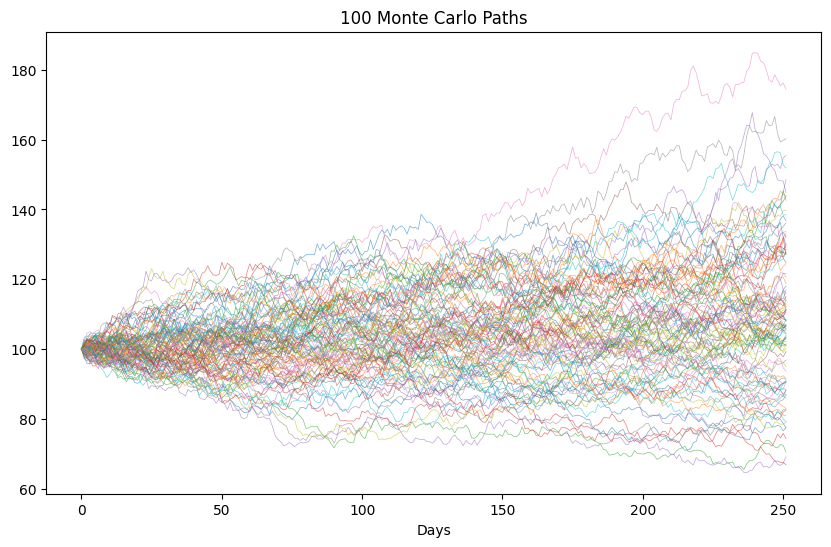

In [5]:
import numpy as np
import matplotlib.pyplot as plt

S0 = 100
mu = 0.08
sigma = 0.2
T = 1
N_steps = 252
dt = T / N_steps
N_sims = 100

paths = np.zeros((N_steps, N_sims))
paths[0] = S0

for t in range(1, N_steps):
    Z = np.random.standard_normal(N_sims)
    paths[t] = paths[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

plt.figure(figsize=(10,6))
plt.plot(paths, lw=0.5, alpha=0.6)
plt.title('100 Monte Carlo Paths')
plt.xlabel('Days')
plt.show()

## The Cone of Uncertainty

- As time progresses, the variance of possible outcomes expands. We can visualize this by plotting the 5th and 95th percentiles over time (the 90% confidence interval).

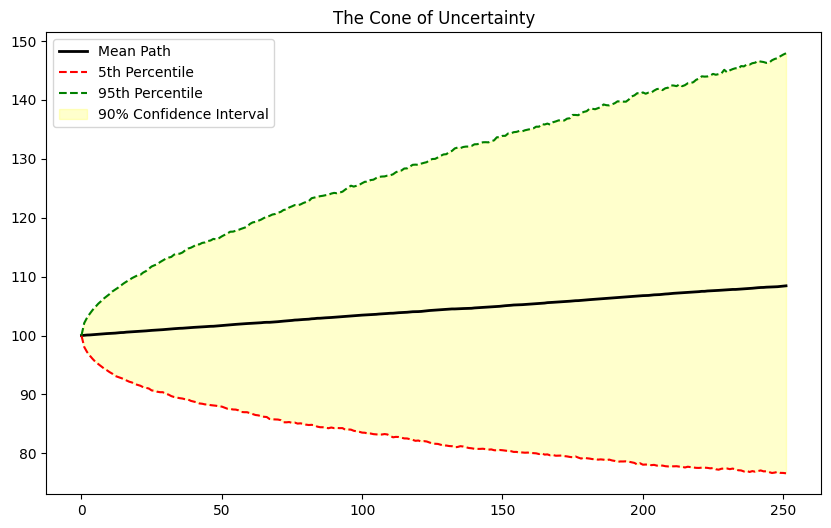

In [2]:
N_sims_large = 10000
paths_large = np.zeros((N_steps, N_sims_large))
paths_large[0] = S0

for t in range(1, N_steps):
    Z = np.random.standard_normal(N_sims_large)
    paths_large[t] = paths_large[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

mean_path = np.mean(paths_large, axis=1)
p_05 = np.percentile(paths_large, 5, axis=1)
p_95 = np.percentile(paths_large, 95, axis=1)

plt.figure(figsize=(10,6))
plt.plot(mean_path, color='black', linewidth=2, label='Mean Path')
plt.plot(p_05, color='red', linestyle='--', label='5th Percentile')
plt.plot(p_95, color='green', linestyle='--', label='95th Percentile')
plt.fill_between(range(N_steps), p_05, p_95, color='yellow', alpha=0.2, label='90% Confidence Interval')
plt.title('The Cone of Uncertainty')
plt.legend()
plt.show()

## Law of Large Numbers (LLN)

- The accuracy of Monte Carlo depends on $N$. Let's plot the estimated mean as we increase $N$ to show it converging to the true theoretical mean $S_0 e^{\mu T}$.

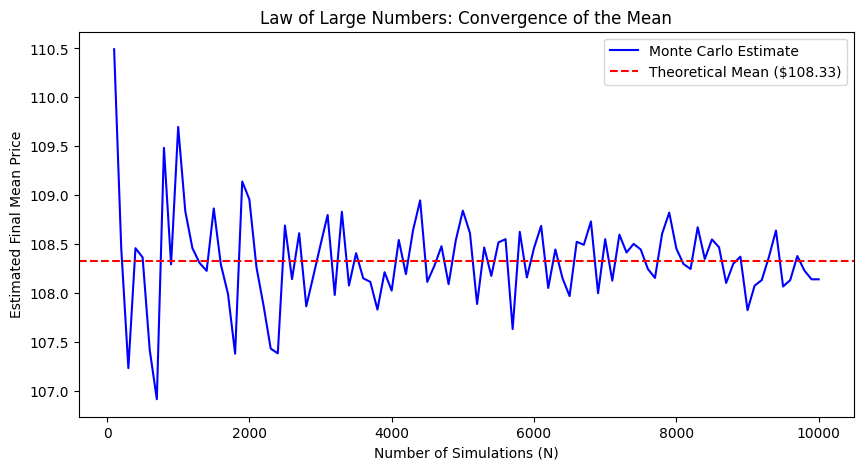

In [3]:
theoretical_mean = S0 * np.exp(mu * T)
sim_counts = np.arange(100, 10100, 100)
estimated_means = []

for n in sim_counts:
    Z_n = np.random.standard_normal(n)
    ST_n = S0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z_n)
    estimated_means.append(ST_n.mean())

plt.figure(figsize=(10,5))
plt.plot(sim_counts, estimated_means, color='blue', label='Monte Carlo Estimate')
plt.axhline(theoretical_mean, color='red', linestyle='--', label=f'Theoretical Mean (${theoretical_mean:.2f})')
plt.title('Law of Large Numbers: Convergence of the Mean')
plt.xlabel('Number of Simulations (N)')
plt.ylabel('Estimated Final Mean Price')
plt.legend()
plt.show()

## Questions for Understanding

- Looking at the Cone of Uncertainty, why do the percentile bounds widen as time progresses?
- If you only run $N=100$ simulations to price a multi-million dollar derivative, what does the LLN convergence plot tell you about the risk of doing so?